Cell 1 — Install required libraries

In [42]:
!pip install minisom kagglehub scikit-learn seaborn scipy plotly -q

Cell 2 — Import libraries

In [43]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.stats import f_oneway
from minisom import MiniSom

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

Cell 3 — Download dataset from Kaggle

In [44]:
import kagglehub

path = kagglehub.dataset_download("arjunbhasin2013/ccdata")
print("Dataset downloaded to:", path)

files = os.listdir(path)
print("Files in dataset folder:", files)

Dataset downloaded to: /home/glitchedpotato/.cache/kagglehub/datasets/arjunbhasin2013/ccdata/versions/1
Files in dataset folder: ['CC GENERAL.csv']


Cell 4 — Load dataset

In [45]:
csv_file = None
for f in os.listdir(path):
    if f.endswith(".csv"):
        csv_file = os.path.join(path, f)
        break

df = pd.read_csv(csv_file)
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


Cell 5 — Basic dataset inspection

In [46]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nInfo:")
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

Shape: (8950, 18)

Columns:
 ['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6  

Cell 6 — Keep customer ID separately

In [47]:
if "CUST_ID" in df.columns:
    cust_ids = df["CUST_ID"].copy()
    df = df.drop(columns=["CUST_ID"])
else:
    cust_ids = pd.Series(range(len(df)), name="CUST_ID")

Cell 7 — Descriptive statistics

In [48]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


Cell 8 — Missing value handling

In [49]:
imputer = SimpleImputer(strategy="median")
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print("Missing values after imputation:\n")
print(df_imputed.isnull().sum().sum())
df_imputed.head()

Missing values after imputation:

0


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,312.343947,0.000000,12.0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0


Cell 9 — Histograms for all features

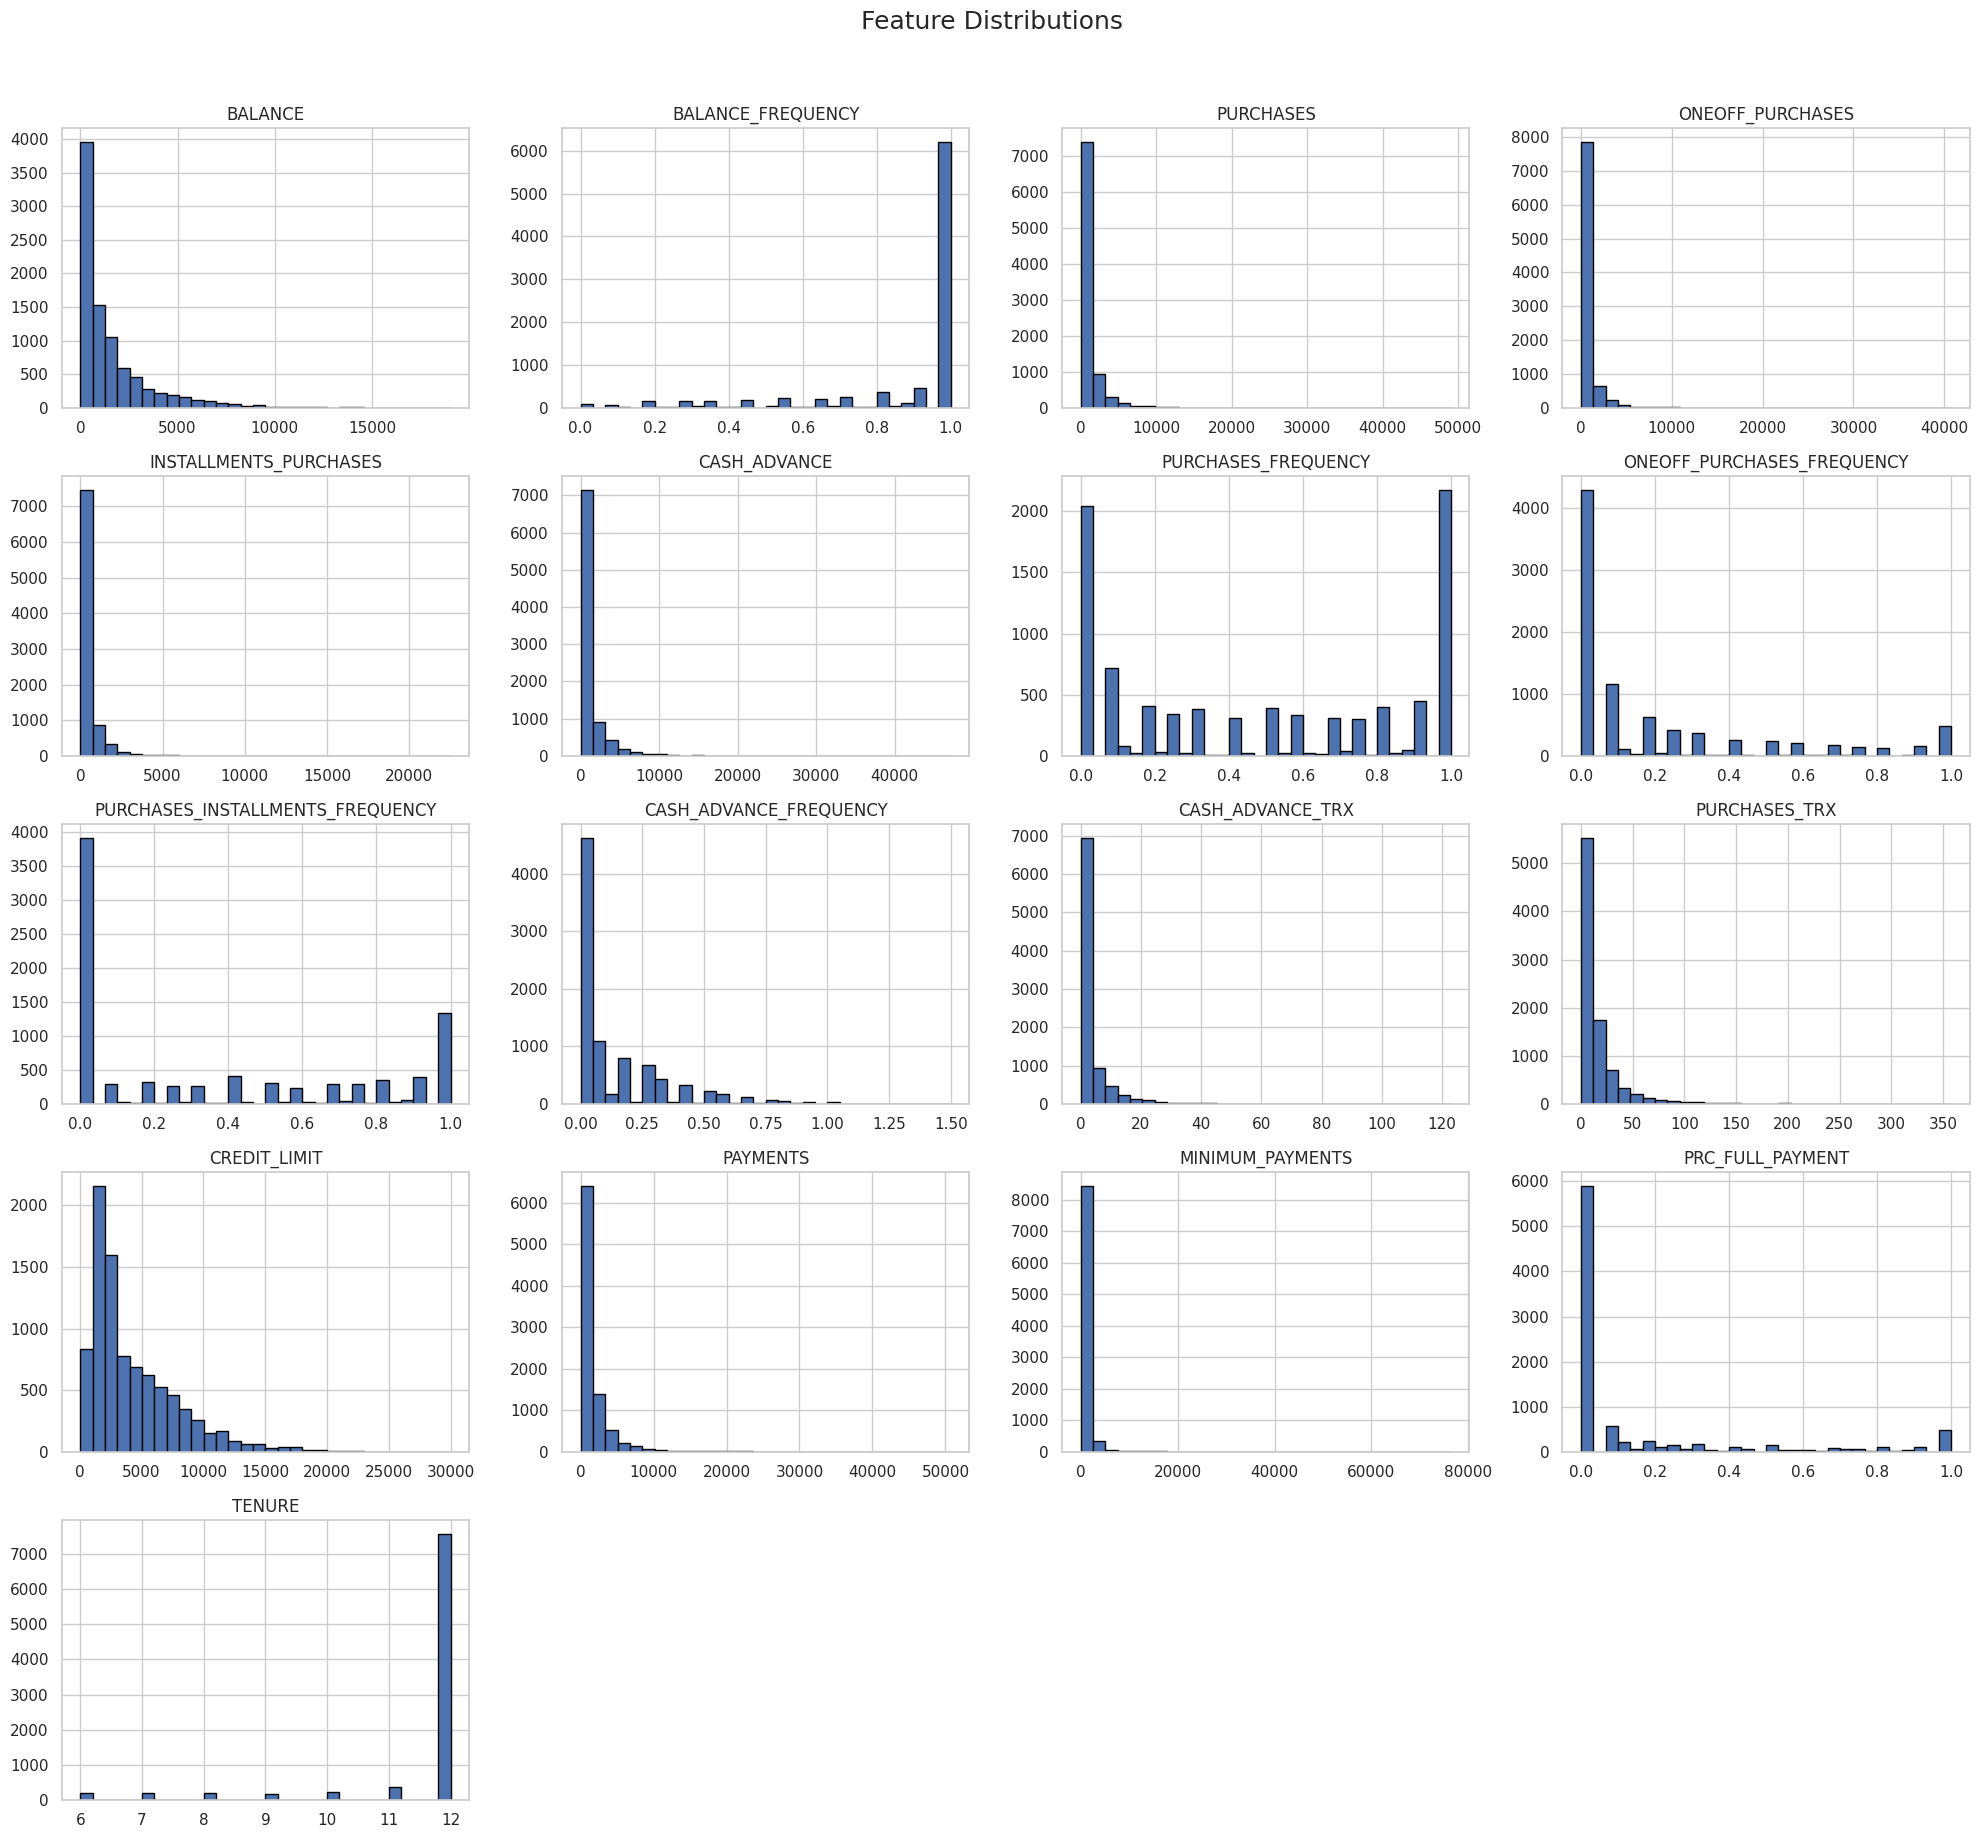

In [50]:
df_imputed.hist(bins=30, figsize=(20, 18), edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

Cell 10 — Boxplots to inspect outliers

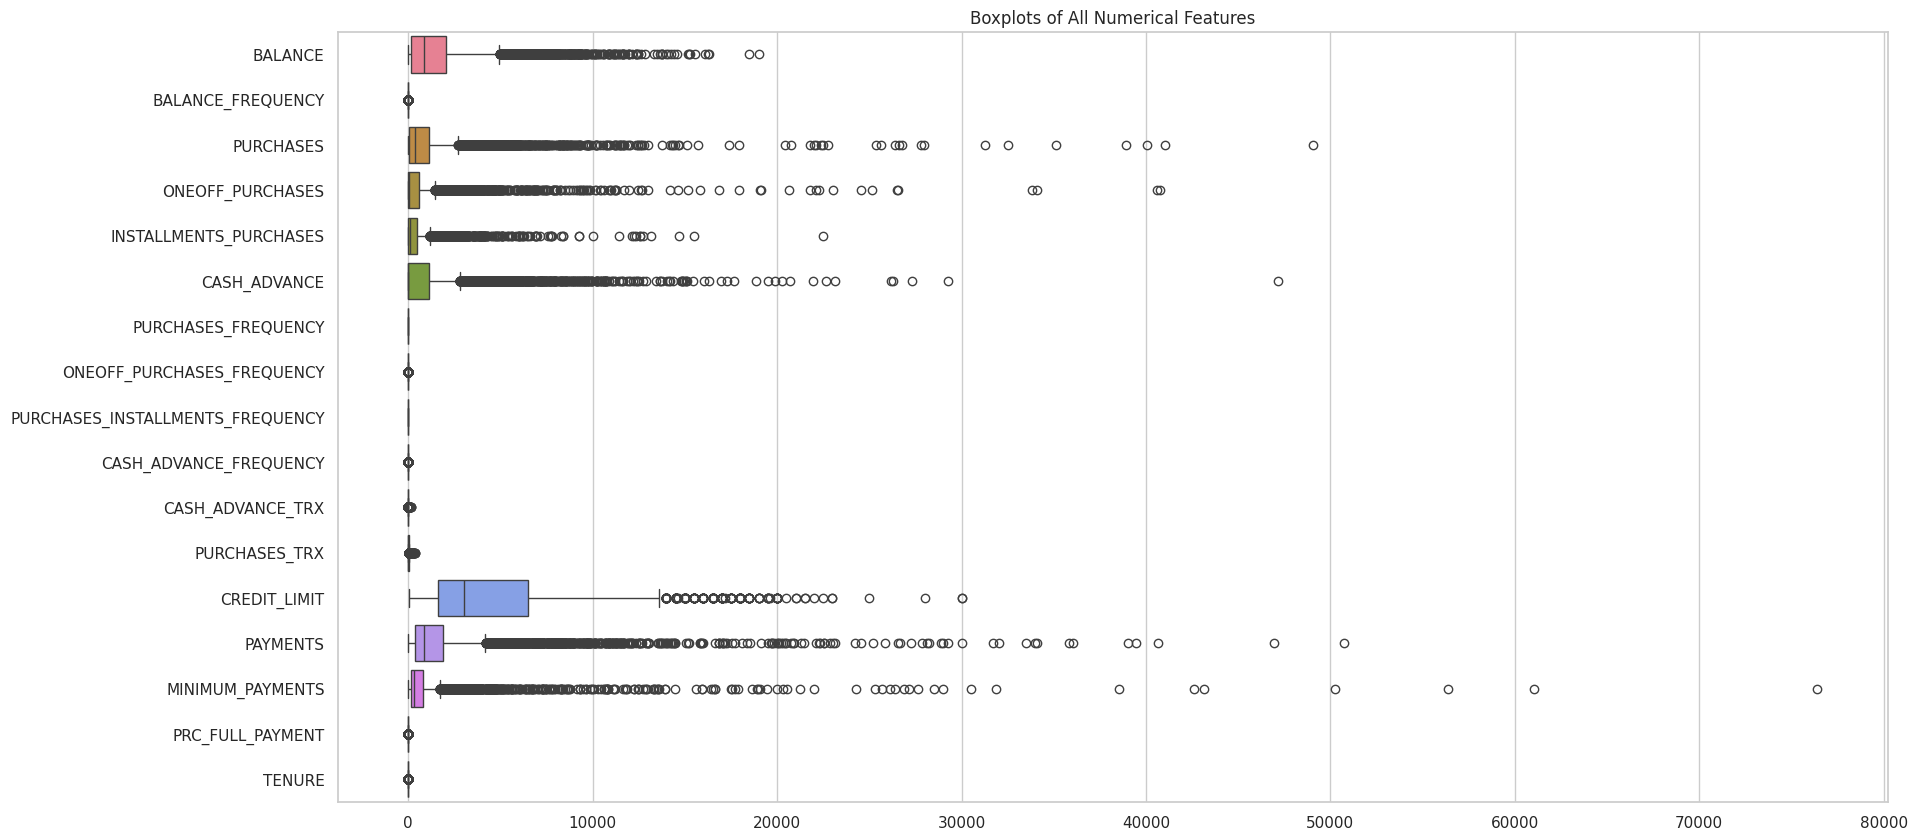

In [51]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=df_imputed, orient="h")
plt.title("Boxplots of All Numerical Features")
plt.show()

Cell 11 — Correlation heatmap

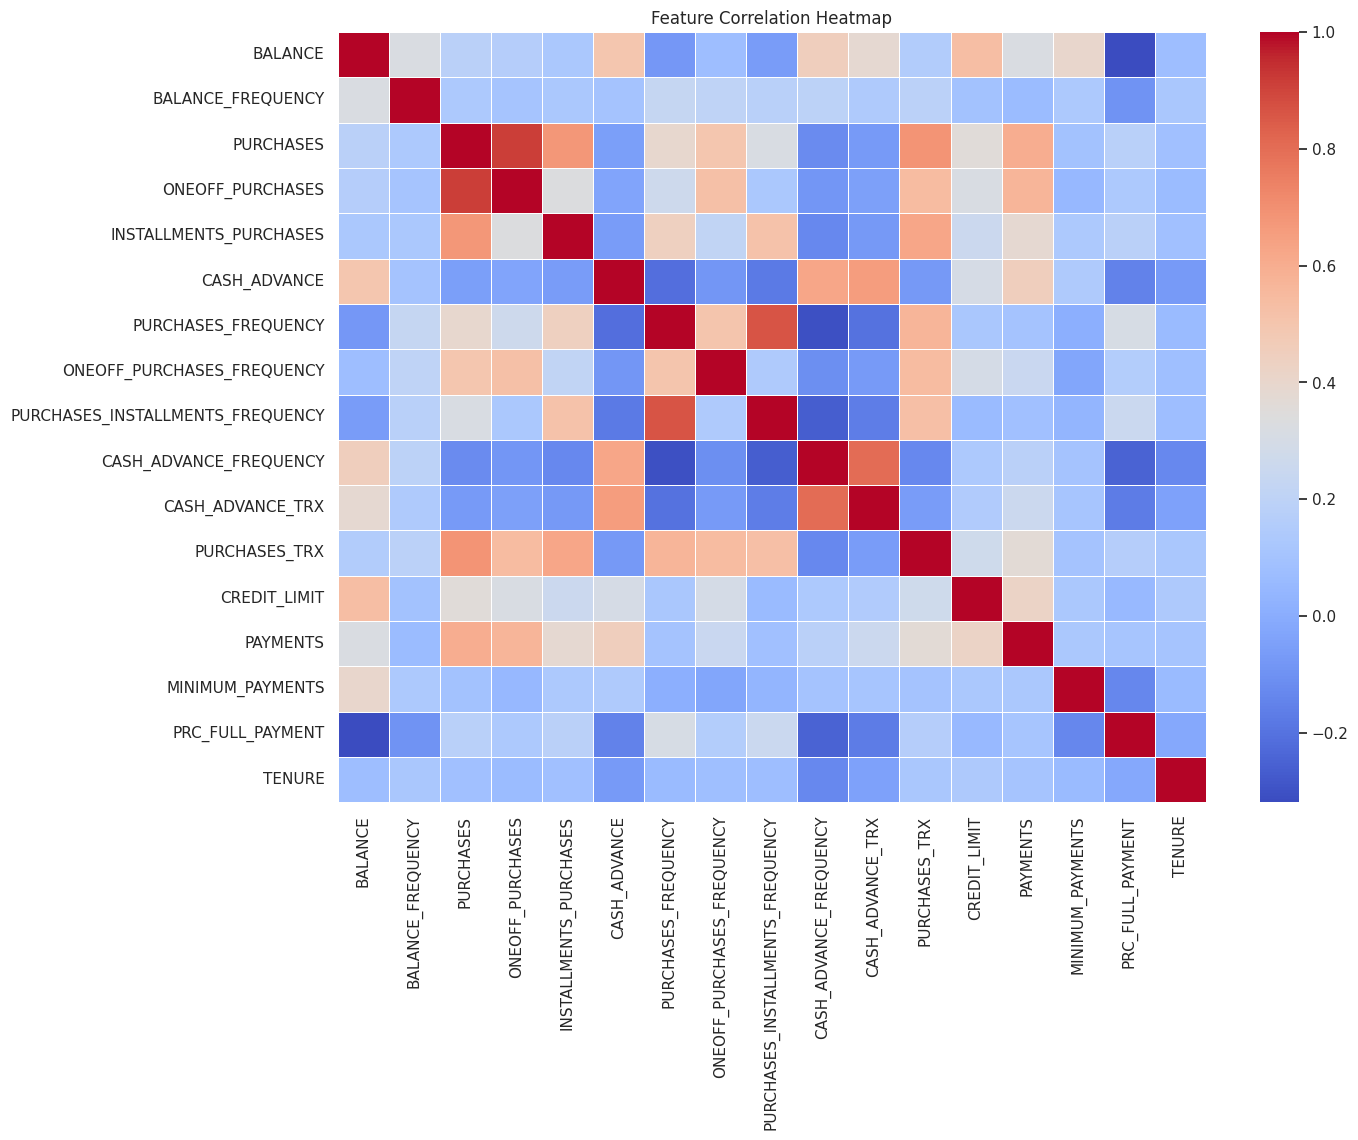

In [52]:
plt.figure(figsize=(14, 10))
corr = df_imputed.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

Cell 12 — IQR-based outlier counts

In [53]:
outlier_summary = {}

for col in df_imputed.columns:
    Q1 = df_imputed[col].quantile(0.25)
    Q3 = df_imputed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_imputed[col] < lower) | (df_imputed[col] > upper)).sum()
    outlier_summary[col] = outliers

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["Outlier_Count"])
outlier_df.sort_values(by="Outlier_Count", ascending=False)

,Outlier_Count
BALANCE_FREQUENCY,1493
PRC_FULL_PAYMENT,1474
TENURE,1366
CASH_ADVANCE,1030
ONEOFF_PURCHASES,1013
MINIMUM_PAYMENTS,909
INSTALLMENTS_PURCHASES,867
PAYMENTS,808
PURCHASES,808
CASH_ADVANCE_TRX,804


Cell 13 — Feature engineering

In [54]:
df_feat = df_imputed.copy()

eps = 1e-6

if {"PURCHASES", "CREDIT_LIMIT"}.issubset(df_feat.columns):
    df_feat["PURCHASES_TO_LIMIT"] = df_feat["PURCHASES"] / (df_feat["CREDIT_LIMIT"] + eps)

if {"PAYMENTS", "MINIMUM_PAYMENTS"}.issubset(df_feat.columns):
    df_feat["PAYMENT_TO_MINPAY"] = df_feat["PAYMENTS"] / (df_feat["MINIMUM_PAYMENTS"] + eps)

if {"BALANCE", "CREDIT_LIMIT"}.issubset(df_feat.columns):
    df_feat["BALANCE_TO_LIMIT"] = df_feat["BALANCE"] / (df_feat["CREDIT_LIMIT"] + eps)

if {"CASH_ADVANCE", "PURCHASES"}.issubset(df_feat.columns):
    df_feat["CASH_TO_PURCHASES"] = df_feat["CASH_ADVANCE"] / (df_feat["PURCHASES"] + eps)

df_feat.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,PURCHASES_TO_LIMIT,PAYMENT_TO_MINPAY,BALANCE_TO_LIMIT,CASH_TO_PURCHASES
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,...,2.0,1000.0,201.802084,139.509787,0.000000,12.0,0.095400,1.446508,0.040901,0.000000e+00
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,...,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,0.000000,3.826241,0.457495,6.442945e+09
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,...,12.0,7500.0,622.066742,627.284787,0.000000,12.0,0.103089,0.991682,0.332687,0.000000e+00
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,...,1.0,7500.0,0.000000,312.343947,0.000000,12.0,0.199867,0.000000,0.222223,1.372835e-01
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,...,1.0,1200.0,678.334763,244.791237,0.000000,12.0,0.013333,2.771075,0.681429,0.000000e+00


Cell 14 — Create a simple categorical segment feature

In [55]:
if "PURCHASES" in df_feat.columns:
    df_feat["PURCHASE_SEGMENT"] = pd.qcut(
        df_feat["PURCHASES"],
        q=3,
        labels=["Low", "Medium", "High"]
    )
    
df_feat["PURCHASE_SEGMENT"].value_counts() if "PURCHASE_SEGMENT" in df_feat.columns else "Segment not created"

PURCHASE_SEGMENT
High      2984
Low       2983
Medium    2983
Name: count, dtype: int64

Cell 15 — Encode categorical feature if present

In [56]:
df_model = df_feat.copy()

if "PURCHASE_SEGMENT" in df_model.columns:
    df_model["PURCHASE_SEGMENT"] = df_model["PURCHASE_SEGMENT"].astype("category").cat.codes

df_model.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,PURCHASES_TO_LIMIT,PAYMENT_TO_MINPAY,BALANCE_TO_LIMIT,CASH_TO_PURCHASES,PURCHASE_SEGMENT
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,...,1000.0,201.802084,139.509787,0.000000,12.0,0.095400,1.446508,0.040901,0.000000e+00,0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,...,7000.0,4103.032597,1072.340217,0.222222,12.0,0.000000,3.826241,0.457495,6.442945e+09,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,...,7500.0,622.066742,627.284787,0.000000,12.0,0.103089,0.991682,0.332687,0.000000e+00,2
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,...,7500.0,0.000000,312.343947,0.000000,12.0,0.199867,0.000000,0.222223,1.372835e-01,2
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,...,1200.0,678.334763,244.791237,0.000000,12.0,0.013333,2.771075,0.681429,0.000000e+00,0


Cell 16 — Min-Max scaling

In [57]:
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(df_model)

X_minmax_df = pd.DataFrame(X_minmax, columns=df_model.columns)
X_minmax_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,PURCHASES_TO_LIMIT,PAYMENT_TO_MINPAY,BALANCE_TO_LIMIT,CASH_TO_PURCHASES,PURCHASE_SEGMENT
0,0.002148,0.818182,0.001945,0.000000,0.00424,0.000000,0.166667,0.000000,0.083333,0.000000,...,0.031720,0.003979,0.001826,0.000000,1.0,0.011104,0.000211,0.002571,0.000000e+00,0.0
1,0.168169,0.909091,0.000000,0.000000,0.00000,0.136685,0.000000,0.000000,0.000000,0.166667,...,0.232053,0.080893,0.014034,0.222222,1.0,0.000000,0.000559,0.028755,2.459698e-01,0.0
2,0.131026,1.000000,0.015766,0.018968,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.248748,0.012264,0.008210,0.000000,1.0,0.011999,0.000145,0.020911,0.000000e+00,1.0
3,0.087521,0.636364,0.030567,0.036775,0.00000,0.004366,0.083333,0.083333,0.000000,0.055555,...,0.248748,0.000000,0.004088,0.000000,1.0,0.023264,0.000000,0.013968,5.241020e-12,1.0
4,0.042940,1.000000,0.000326,0.000393,0.00000,0.000000,0.083333,0.083333,0.000000,0.000000,...,0.038397,0.013374,0.003204,0.000000,1.0,0.001552,0.000405,0.042830,0.000000e+00,0.0


Cell 17 — Standard scaling

In [58]:
std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(df_model)

X_std_df = pd.DataFrame(X_std, columns=df_model.columns)
X_std_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,PURCHASES_TO_LIMIT,PAYMENT_TO_MINPAY,BALANCE_TO_LIMIT,CASH_TO_PURCHASES,PURCHASE_SEGMENT
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,...,-0.960378,-0.528979,-0.302400,-0.525551,0.36068,-0.382946,-0.064420,-0.892951,-0.314134,-1.224848
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,...,0.688678,0.818642,0.097500,0.234227,0.36068,-0.601434,-0.044282,0.176063,4.142052,-1.224848
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,...,0.826100,-0.383805,-0.093293,-0.525551,0.36068,-0.365336,-0.068269,-0.144206,-0.314134,1.224574
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,...,0.826100,-0.598688,-0.228307,-0.525551,0.36068,-0.143694,-0.076661,-0.427665,-0.314134,1.224574
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,...,-0.905410,-0.364368,-0.257266,-0.525551,0.36068,-0.570897,-0.053211,0.750693,-0.314134,-1.224848


Cell 18 — Compare Min-Max vs Standard scaling summary

In [59]:
comparison_df = pd.DataFrame({
    "MinMax_Mean": X_minmax_df.mean(),
    "MinMax_Std": X_minmax_df.std(),
    "StdScaler_Mean": X_std_df.mean(),
    "StdScaler_Std": X_std_df.std()
})

comparison_df.head(10)

,MinMax_Mean,MinMax_Std,StdScaler_Mean,StdScaler_Std
BALANCE,0.082154,0.109306,-2.540488e-17,1.000056
BALANCE_FREQUENCY,0.877271,0.236904,1.587805e-16,1.000056
PURCHASES,0.020457,0.043570,3.175610e-18,1.000056
ONEOFF_PURCHASES,0.014534,0.040722,-6.033659e-17,1.000056
INSTALLMENTS_PURCHASES,0.018270,0.040193,3.175610e-17,1.000056
CASH_ADVANCE,0.020766,0.044491,-6.351220e-18,1.000056
PURCHASES_FREQUENCY,0.490351,0.401371,9.328354e-17,1.000056
ONEOFF_PURCHASES_FREQUENCY,0.202458,0.298336,1.905366e-17,1.000056
PURCHASES_INSTALLMENTS_FREQUENCY,0.364437,0.397448,5.716098e-17,1.000056
CASH_ADVANCE_FREQUENCY,0.090096,0.133414,-1.595744e-16,1.000056


Cell 19 — PCA to 2D for visualization

In [60]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_std)

pca_df = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])
pca_df.head()

,PC1,PC2
0,-1.629983,-1.689835
1,-2.780457,3.038611
2,1.318133,-0.216469
3,-0.340486,-0.494225
4,-1.835119,-0.911843


Cell 20 — PCA explained variance

In [61]:
print("Explained variance ratio:", pca_2d.explained_variance_ratio_)
print("Total explained variance:", pca_2d.explained_variance_ratio_.sum())

Explained variance ratio: [0.25873306 0.17956106]
Total explained variance: 0.438294122132486


Cell 21 — PCA 2D scatter plot

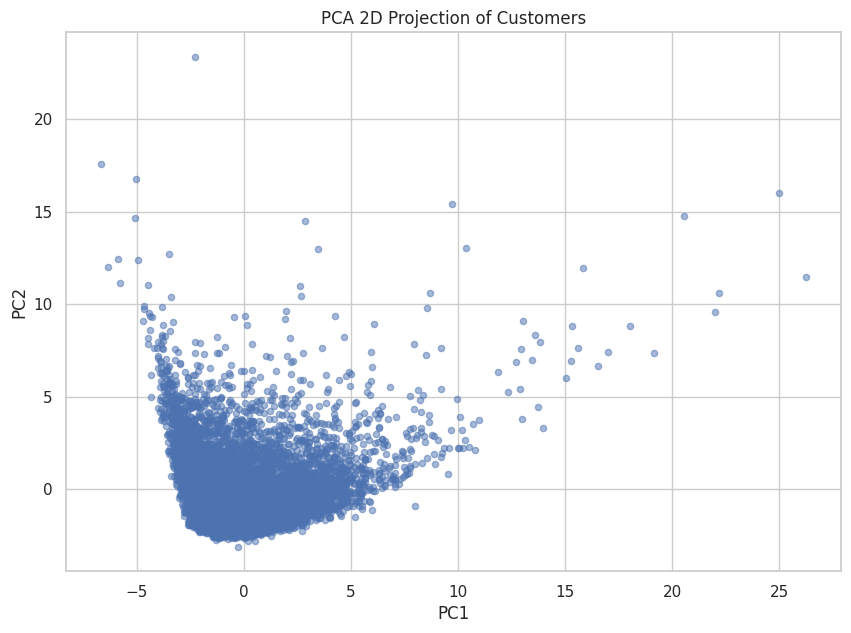

In [62]:
plt.figure(figsize=(10, 7))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.5, s=20)
plt.title("PCA 2D Projection of Customers")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Cell 22 — PCA 3D for later visualization

In [63]:
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_std)

pca3_df = pd.DataFrame(X_pca_3d, columns=["PC1", "PC2", "PC3"])
pca3_df.head()

,PC1,PC2,PC3
0,-1.629983,-1.689835,-0.334178
1,-2.780457,3.038611,-1.865283
2,1.318133,-0.216469,0.569401
3,-0.340486,-0.494225,-0.775460
4,-1.835119,-0.911843,0.683628


Cell 23 — Initialize SOM

In [64]:
som_x = 10
som_y = 10
input_len = X_minmax.shape[1]

som = MiniSom(
    x=som_x,
    y=som_y,
    input_len=input_len,
    sigma=3,
    learning_rate=0.5,
    neighborhood_function="gaussian",
    random_seed=42
)

som.random_weights_init(X_minmax)
print("SOM initialized.")

SOM initialized.


Cell 24 — Train SOM and track quantization error

In [65]:
num_iterations = 10000
q_error = []

for i in range(num_iterations):
    rand_idx = np.random.randint(0, X_minmax.shape[0])
    sample = X_minmax[rand_idx]
    som.update(sample, som.winner(sample), i, num_iterations)
    
    if (i + 1) % 100 == 0:
        q_error.append(som.quantization_error(X_minmax))

print("Training complete.")

Training complete.


Cell 25 — Quantization error convergence plot

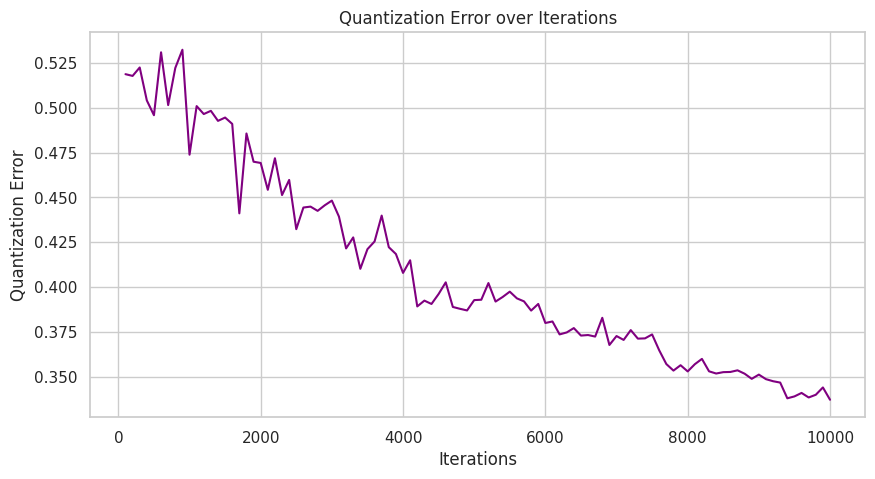

In [66]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(100, num_iterations + 1, 100), q_error, color="purple")
plt.title("Quantization Error over Iterations")
plt.xlabel("Iterations")
plt.ylabel("Quantization Error")
plt.show()

Cell 26 — Save SOM weights

som_weights = som.get_weights()
np.save("som_weights.npy", som_weights)
print("SOM weights saved as som_weights.npy")
print("Weight matrix shape:", som_weights.shape)

Cell 27 — U-Matrix visualization

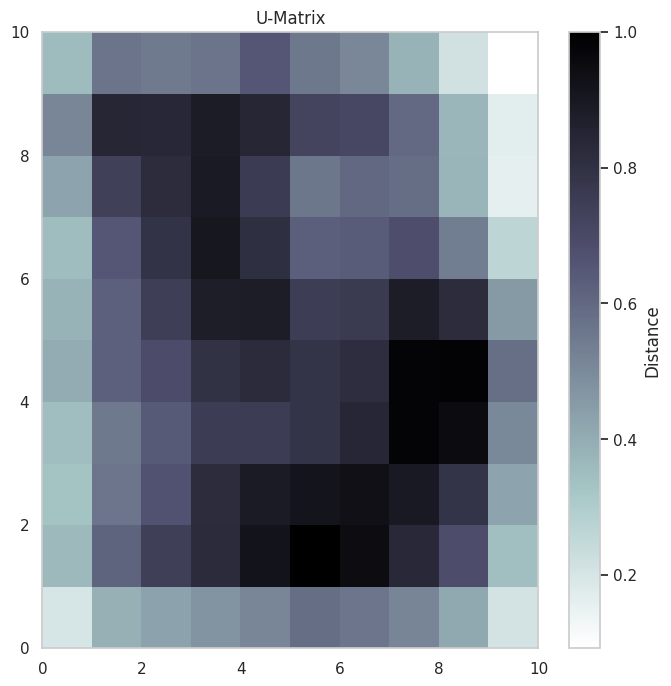

In [67]:
u_matrix = som.distance_map().T

plt.figure(figsize=(8, 8))
plt.pcolor(u_matrix, cmap="bone_r")
plt.colorbar(label="Distance")
plt.title("U-Matrix")
plt.show()

Cell 28 — Hit map visualization

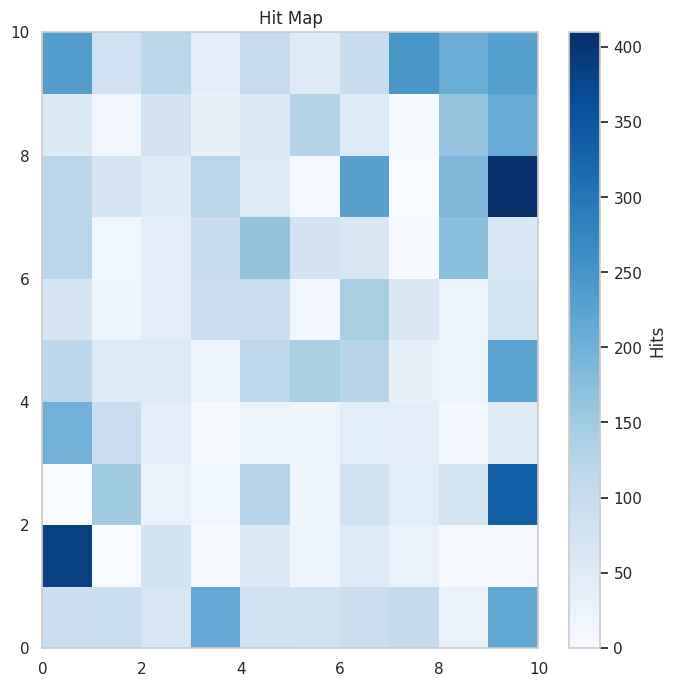

In [68]:
hit_map = np.zeros((som_x, som_y))

for x in X_minmax:
    w = som.winner(x)
    hit_map[w[0], w[1]] += 1

plt.figure(figsize=(8, 8))
plt.pcolor(hit_map.T, cmap="Blues")
plt.colorbar(label="Hits")
plt.title("Hit Map")
plt.show()

Cell 29 — Map each customer to BMU

In [69]:
bmus = np.array([som.winner(x) for x in X_minmax])
bmu_df = pd.DataFrame(bmus, columns=["BMU_X", "BMU_Y"])
bmu_df.head()

,BMU_X,BMU_Y
0,8,6
1,8,9
2,2,8
3,5,6
4,8,6


Cell 30 — Sample mapping plot

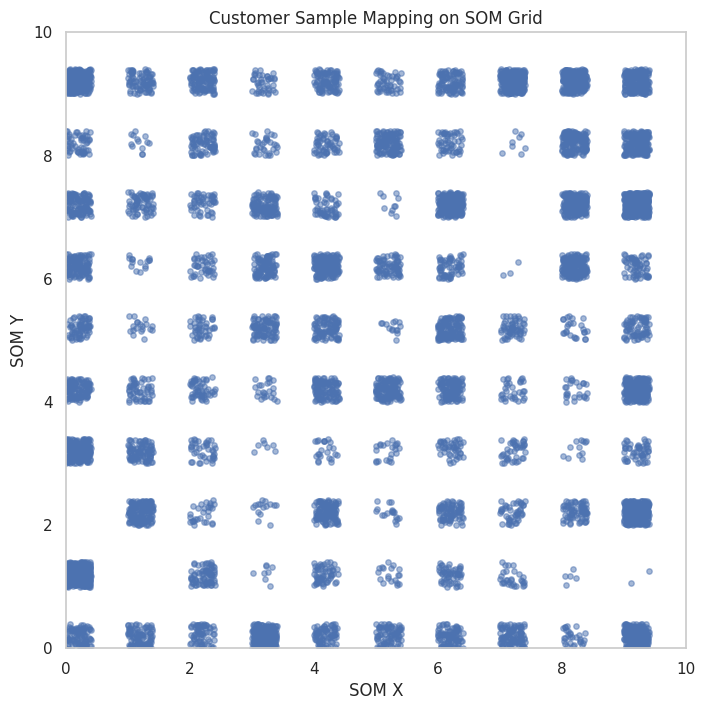

In [70]:
plt.figure(figsize=(8, 8))
plt.scatter(bmus[:, 0] + np.random.rand(len(bmus))*0.4,
            bmus[:, 1] + np.random.rand(len(bmus))*0.4,
            alpha=0.5, s=15)
plt.xlim([0, som_x])
plt.ylim([0, som_y])
plt.title("Customer Sample Mapping on SOM Grid")
plt.xlabel("SOM X")
plt.ylabel("SOM Y")
plt.grid()
plt.show()

Cell 31 — Component planes for all features

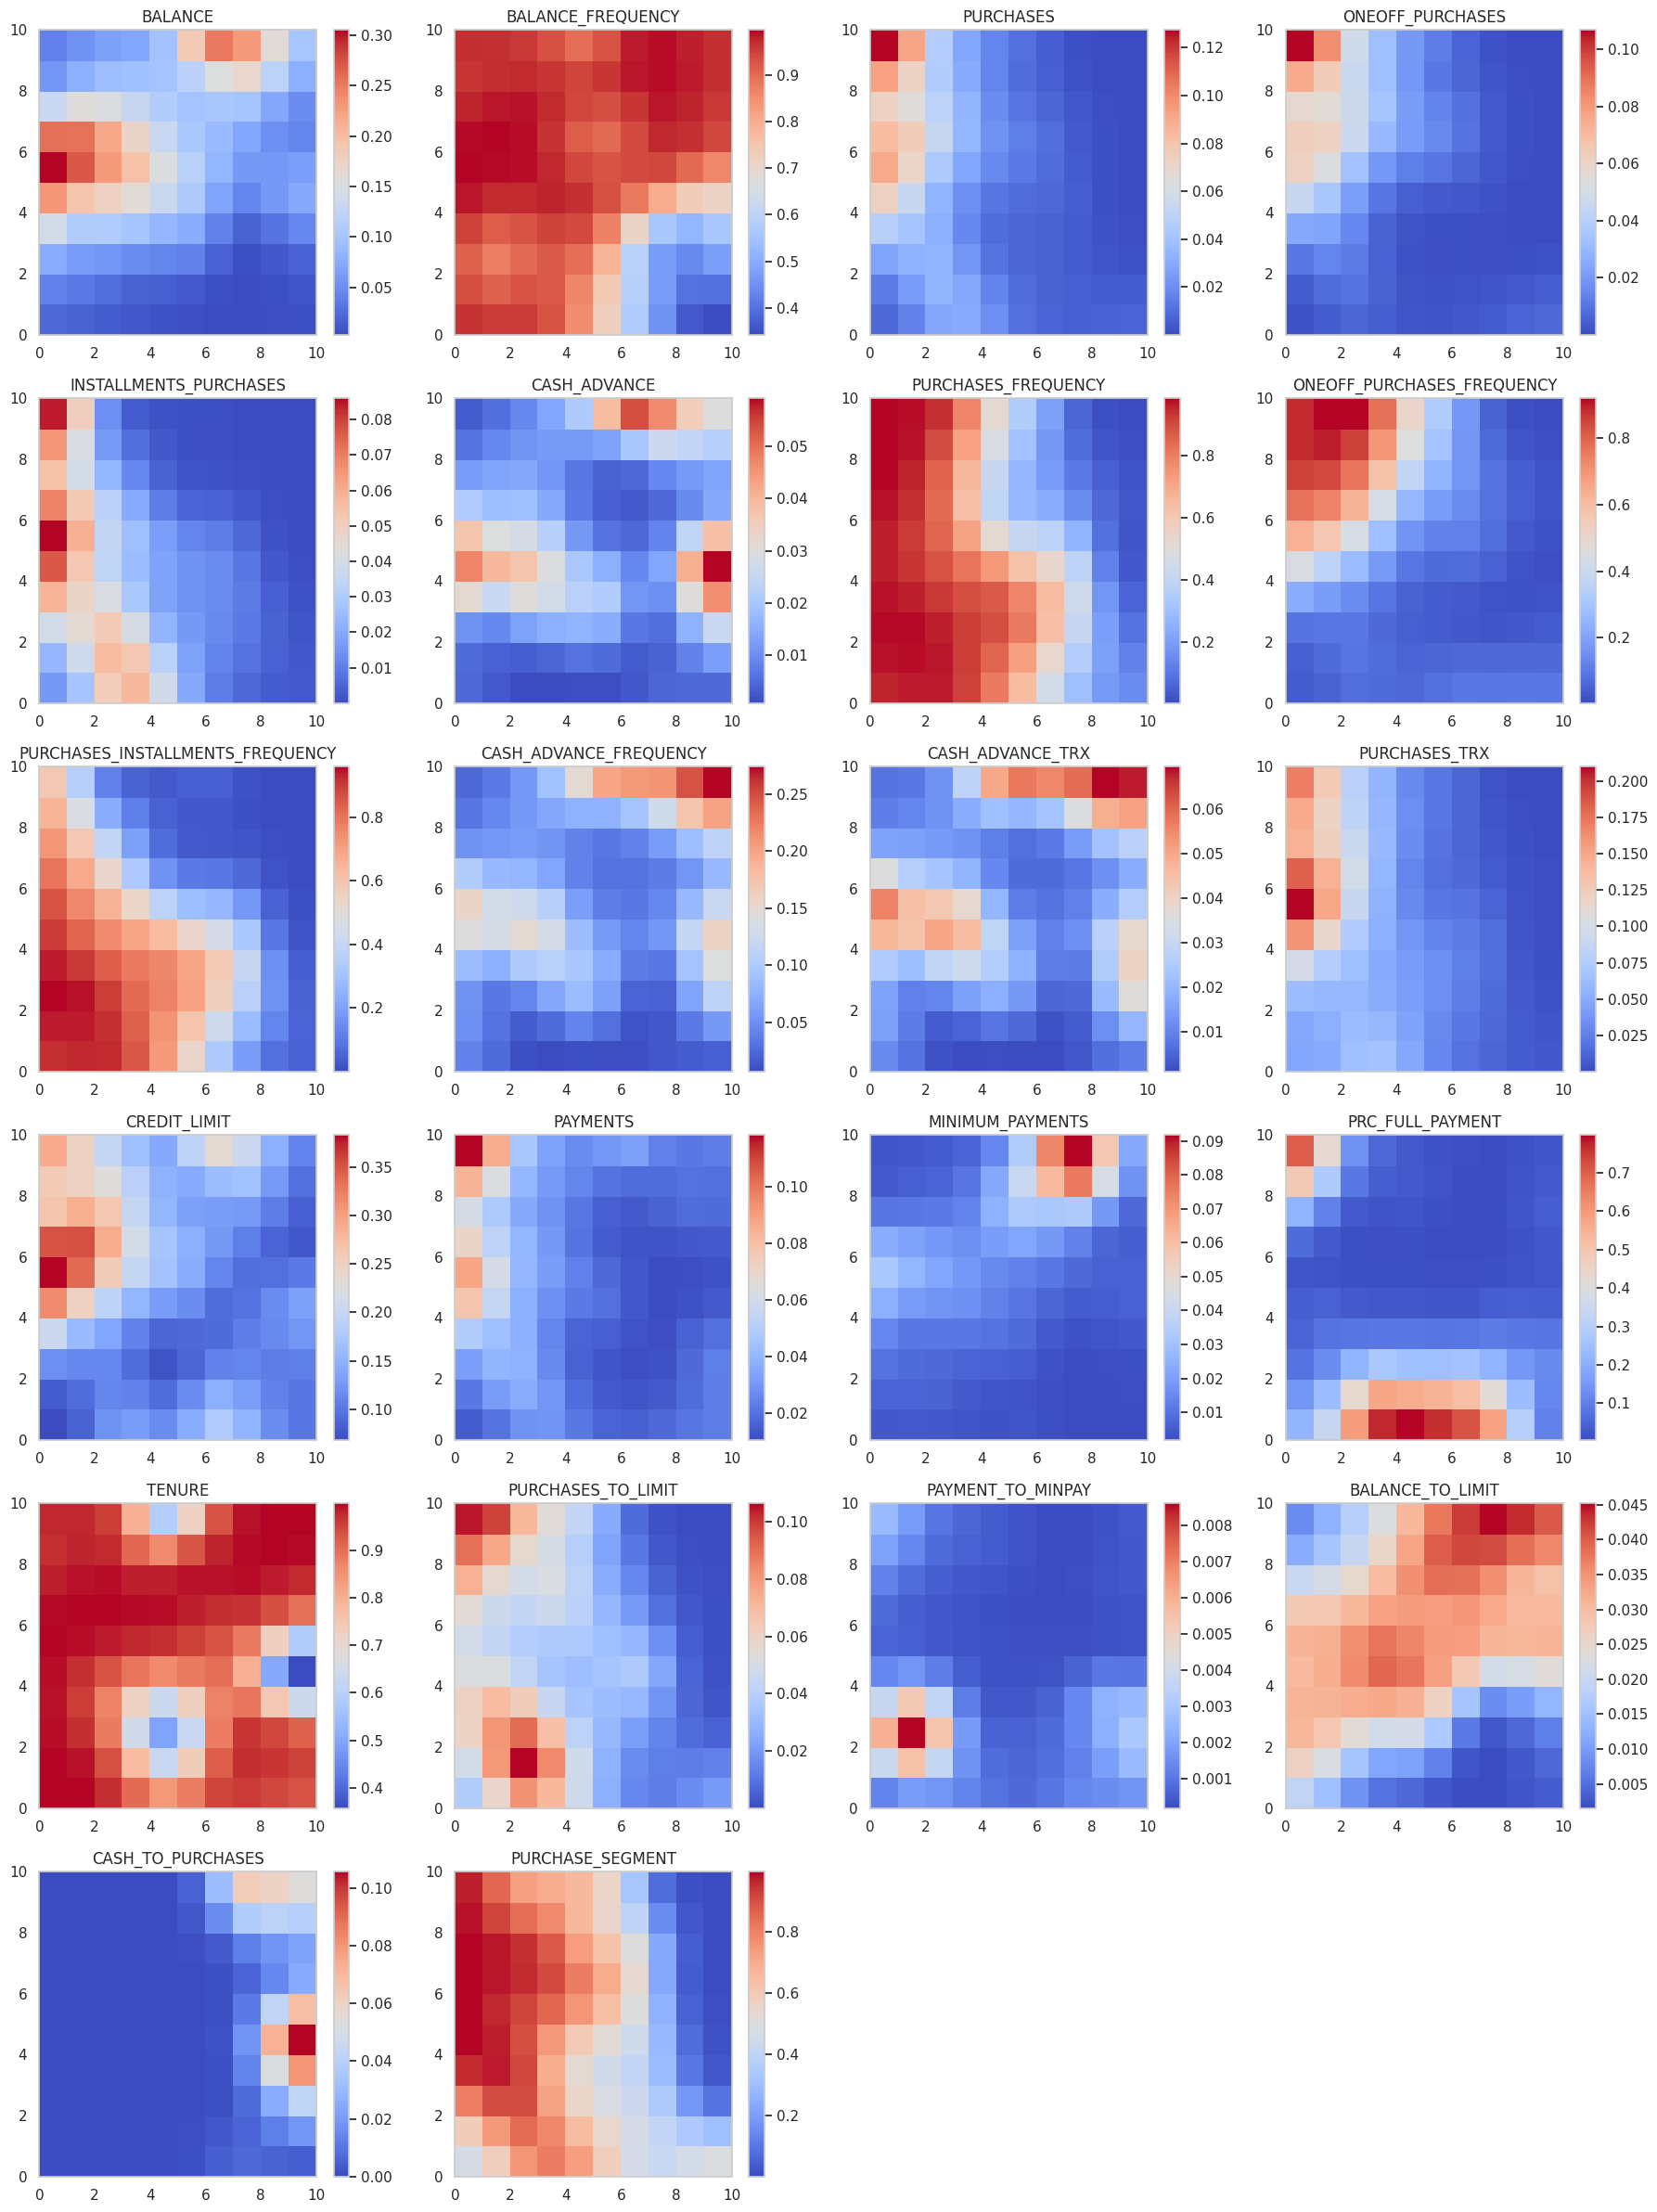

In [71]:
weights = som.get_weights()

n_features = weights.shape[2]
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

plt.figure(figsize=(18, 4 * n_rows))

for i, feature in enumerate(df_model.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.pcolor(weights[:, :, i].T, cmap="coolwarm")
    plt.title(feature)
    plt.colorbar()

plt.tight_layout()
plt.show()

Cell 32 — Cluster SOM neurons using K-means on SOM weights

In [72]:
weight_vectors = weights.reshape(som_x * som_y, input_len)

silhouette_scores = {}
for k in range(3, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(weight_vectors)
    score = silhouette_score(weight_vectors, labels)
    silhouette_scores[k] = score

silhouette_scores

{3: 0.39447973222642263, 4: 0.3331266296206109, 5: 0.3704385943417227}

Cell 33 — Select best cluster count


In [73]:
best_k = max(silhouette_scores, key=silhouette_scores.get)
print("Best k based on silhouette score:", best_k)

Best k based on silhouette score: 3


Cell 34 — Fit final clustering on SOM weights


In [74]:
final_kmeans_weights = KMeans(n_clusters=best_k, random_state=42, n_init=10)
neuron_clusters = final_kmeans_weights.fit_predict(weight_vectors)

cluster_map = neuron_clusters.reshape(som_x, som_y)
cluster_map

array([[2, 2, 2, 2, 0, 0, 0, 0, 0, 0],
       [2, 2, 2, 2, 0, 0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2, 0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2, 0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2, 2, 1, 1, 1, 1],
       [2, 2, 2, 2, 2, 1, 1, 1, 1, 1],
       [1, 2, 2, 2, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=int32)

Cell 35 — Cluster-labeled SOM map

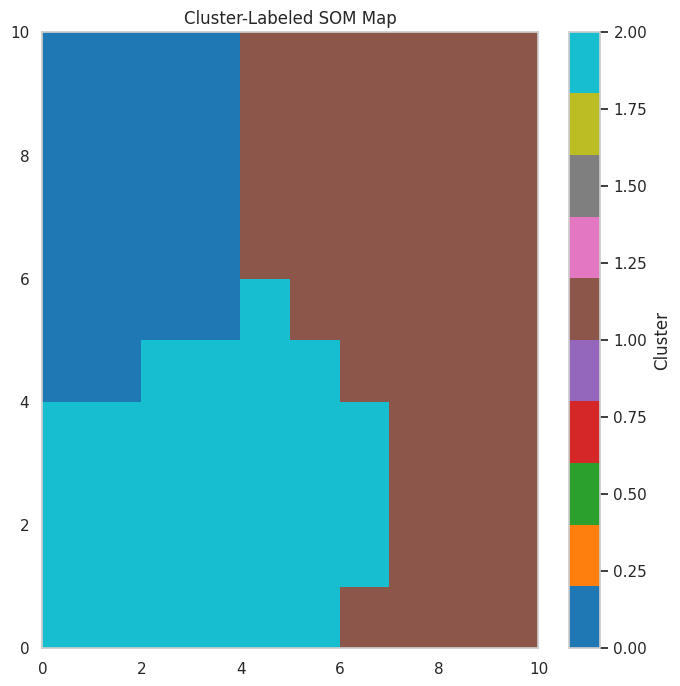

In [75]:
plt.figure(figsize=(8, 8))
plt.pcolor(cluster_map.T, cmap="tab10")
plt.colorbar(label="Cluster")
plt.title("Cluster-Labeled SOM Map")
plt.show()

Cell 36 — Assign cluster to each customer from BMU neuron cluster

In [76]:
customer_clusters = []

for bmu in bmus:
    cluster_id = cluster_map[bmu[0], bmu[1]]
    customer_clusters.append(cluster_id)

customer_clusters = np.array(customer_clusters)

clustered_df = df_imputed.copy()
clustered_df["Cluster"] = customer_clusters
clustered_df["CUST_ID"] = cust_ids.values
clustered_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster,CUST_ID
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,1,C10001
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,1,C10002
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,0,C10003
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,312.343947,0.000000,12.0,1,C10004
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,1,C10005


Cell 37 — Cluster counts and percentages

In [77]:
cluster_counts = clustered_df["Cluster"].value_counts().sort_index()
cluster_percent = round(cluster_counts / len(clustered_df) * 100, 2)

cluster_summary = pd.DataFrame({
    "Count": cluster_counts,
    "Percentage": cluster_percent
})

cluster_summary

,Count,Percentage
Cluster,,
0,1682,18.79
1,4757,53.15
2,2511,28.06


Cell 38 — PCA scatter colored by cluster

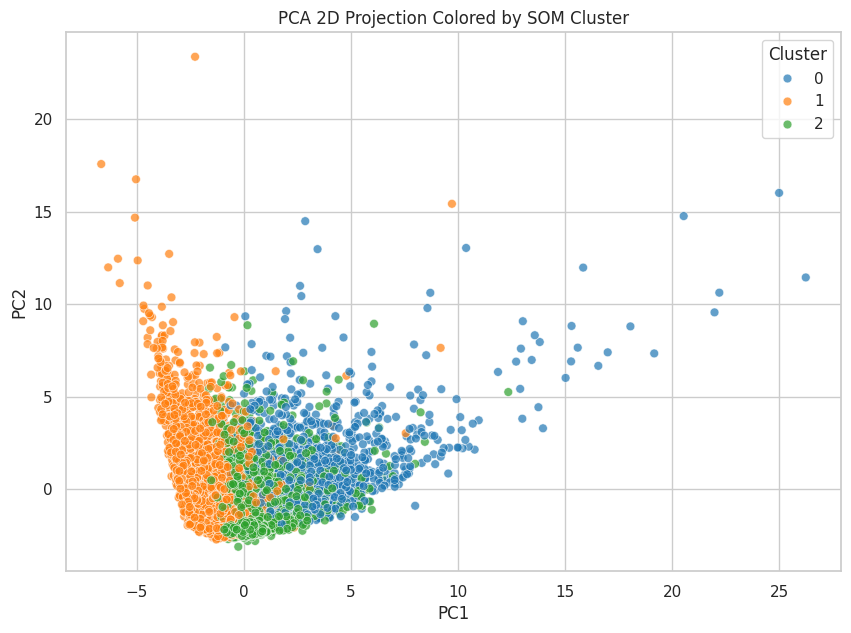

In [78]:
pca_cluster_df = pca_df.copy()
pca_cluster_df["Cluster"] = customer_clusters

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_cluster_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.7,
    s=40
)
plt.title("PCA 2D Projection Colored by SOM Cluster")
plt.show()

Cell 39 — 3D PCA plot colored by cluster

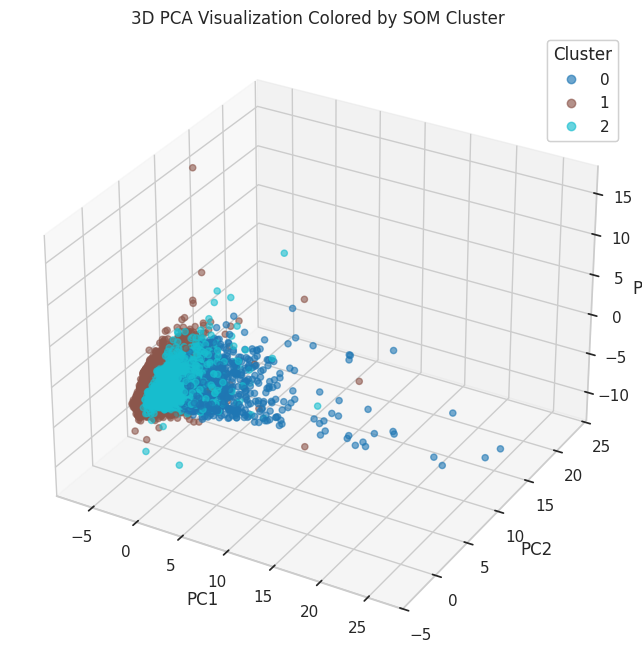

In [79]:
from mpl_toolkits.mplot3d import Axes3D

pca3_cluster_df = pca3_df.copy()
pca3_cluster_df["Cluster"] = customer_clusters

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca3_cluster_df["PC1"],
    pca3_cluster_df["PC2"],
    pca3_cluster_df["PC3"],
    c=pca3_cluster_df["Cluster"],
    cmap="tab10",
    alpha=0.6,
    s=20
)

ax.set_title("3D PCA Visualization Colored by SOM Cluster")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

plt.show()

Cell 40 — Cluster profile means

In [80]:
cluster_profile = clustered_df.groupby("Cluster").mean(numeric_only=True)
cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,2181.491267,0.979383,3134.944174,2237.678912,897.265262,773.391217,0.886544,0.726771,0.532543,0.100515,2.623068,42.162307,6824.630851,3240.332007,897.765759,0.225072,11.873960
1,1647.392659,0.823753,268.977166,219.332941,49.832022,1322.918590,0.149002,0.083543,0.064376,0.183323,4.343704,2.728610,4077.886878,1440.841175,804.789430,0.073682,11.427791
2,994.079855,0.910257,966.221736,197.201012,769.734894,464.726682,0.871632,0.076525,0.820287,0.067067,1.593787,19.018718,3722.139053,1277.306878,885.499894,0.257535,11.448029



Cell 41 — Cluster profile standard deviations

In [81]:
cluster_std = clustered_df.groupby("Cluster").std(numeric_only=True)
cluster_std

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,2653.443788,0.073848,3855.859733,3108.645831,1451.808150,2149.491161,0.152017,0.249670,0.377873,0.188233,6.303405,39.504220,4333.647942,4190.998963,1549.534698,0.346693,0.615717
1,1999.400858,0.277422,722.817418,688.617180,225.338491,2326.511568,0.178047,0.133722,0.129800,0.213846,7.735061,5.041807,3313.436761,2636.135175,2090.538449,0.202154,1.431095
2,1601.277043,0.192646,1122.968638,467.808108,934.667787,1346.584979,0.165460,0.121725,0.195414,0.150224,4.561211,17.721485,3042.920953,1749.186202,3083.284941,0.347517,1.464992


Cell 42 — Heatmap of cluster means

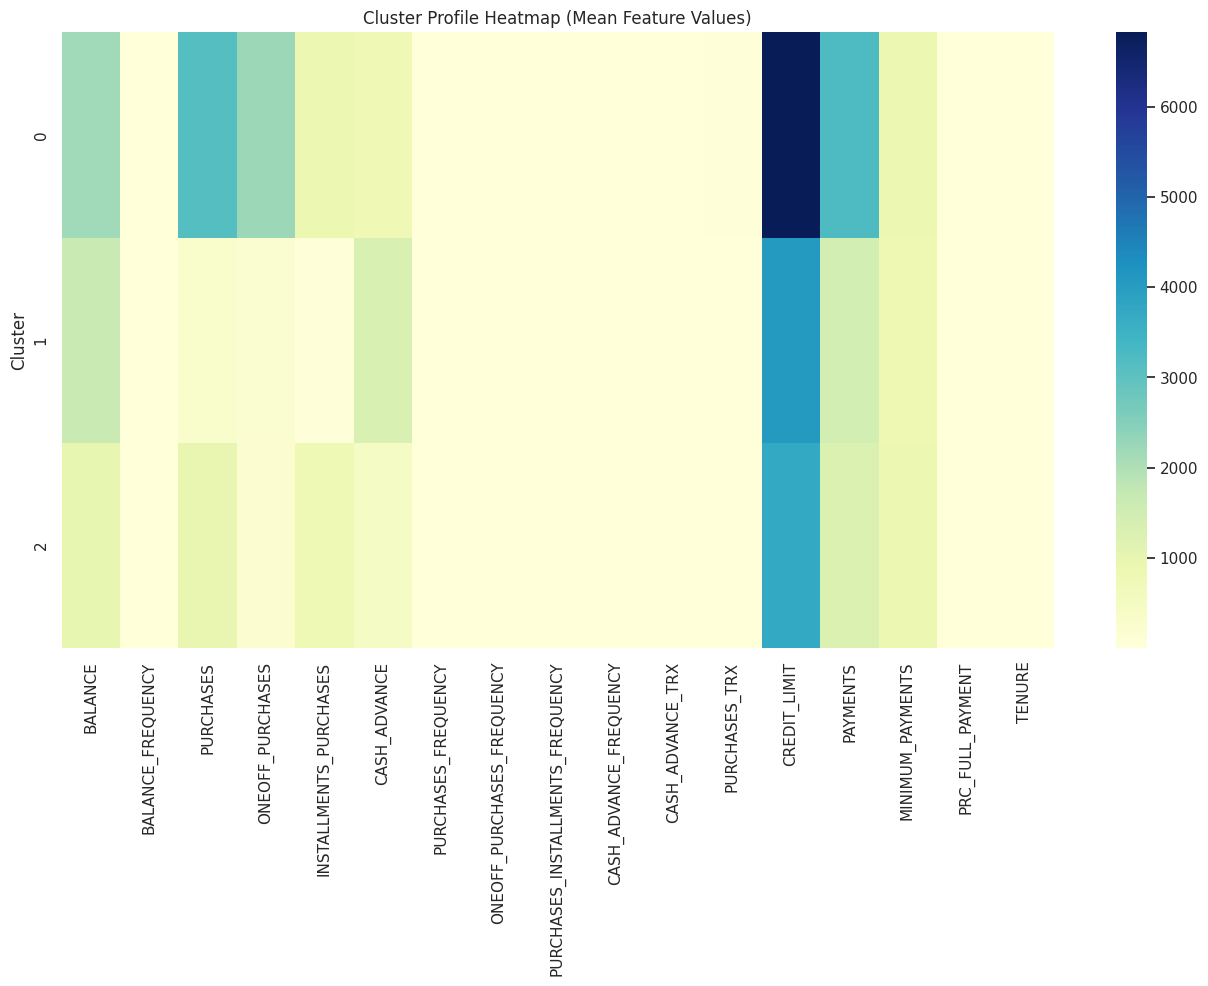

In [82]:
plt.figure(figsize=(16, 8))
sns.heatmap(cluster_profile, cmap="YlGnBu", annot=False)
plt.title("Cluster Profile Heatmap (Mean Feature Values)")
plt.show()

Cell 43 — Radar chart preparation

In [83]:
radar_features = cluster_profile.columns.tolist()

if "CUST_ID" in radar_features:
    radar_features.remove("CUST_ID")

radar_profile = cluster_profile[radar_features].copy()

radar_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(radar_profile),
    columns=radar_profile.columns,
    index=radar_profile.index
)

radar_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1.000000,1.00000,1.000000,1.000000,1.00000,0.359668,1.000000,1.000000,0.619341,0.287713,0.374295,1.000000,1.000000,1.000000,1.000000,0.823431,1.00000
1,0.550199,0.00000,0.000000,0.010846,0.00000,1.000000,0.000000,0.010793,0.000000,1.000000,1.000000,0.000000,0.114665,0.083307,0.000000,0.000000,0.00000
2,0.000000,0.55583,0.243284,0.000000,0.84951,0.000000,0.979781,0.000000,1.000000,0.000000,0.000000,0.413101,0.000000,0.000000,0.868075,1.000000,0.04536


Cell 44 — Radar chart for cluster comparison

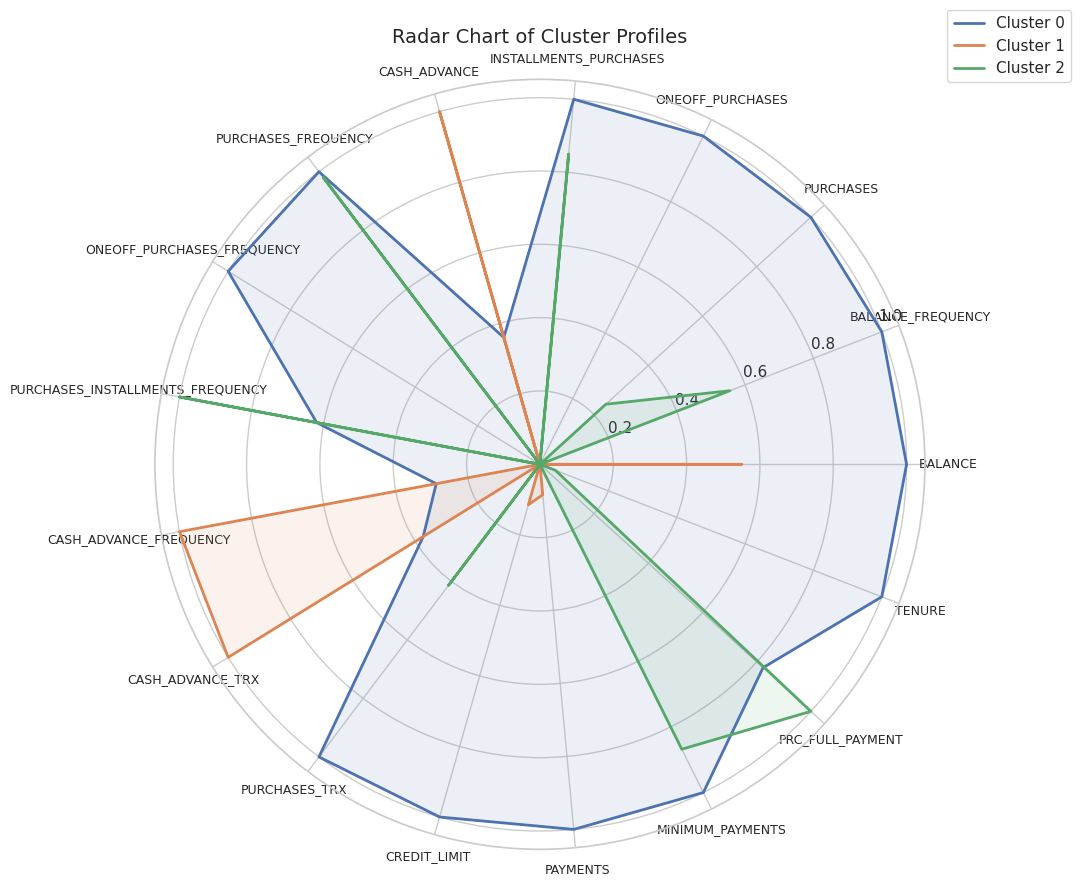

In [84]:
from math import pi

categories = radar_scaled.columns.tolist()
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

for idx in radar_scaled.index:
    values = radar_scaled.loc[idx].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f"Cluster {idx}")
    ax.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], categories, size=9)
plt.title("Radar Chart of Cluster Profiles", size=14)
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
plt.show()

Cell 45 — Boxplots of important features by cluster


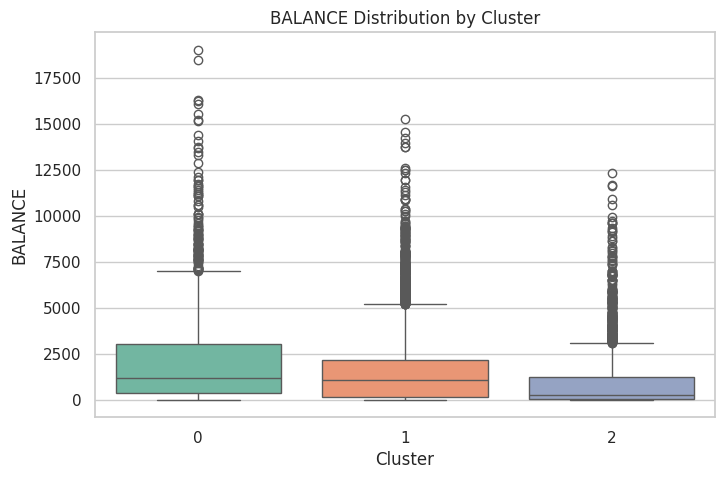

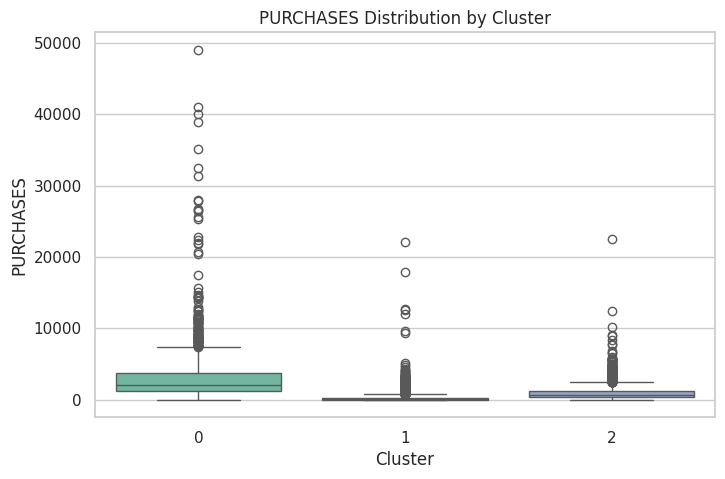

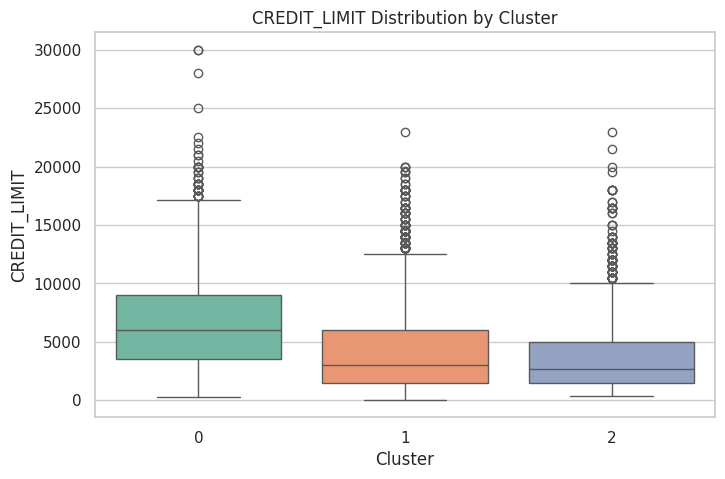

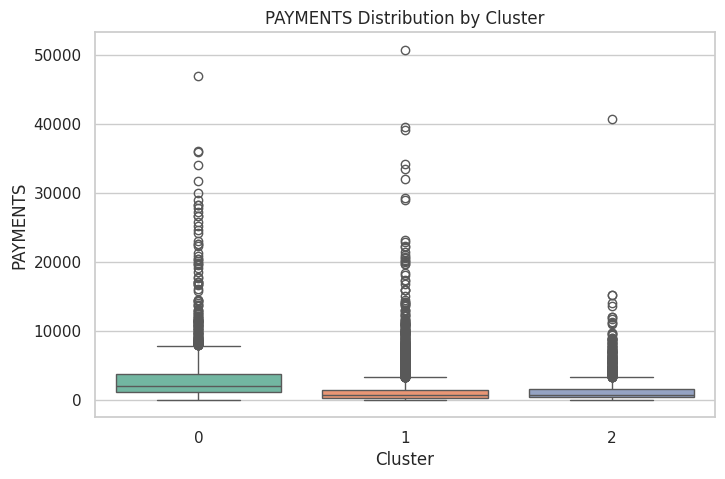

In [85]:
important_features = ["BALANCE", "PURCHASES", "CREDIT_LIMIT", "PAYMENTS"]

for feature in important_features:
    if feature in clustered_df.columns:
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=clustered_df, x="Cluster", y=feature, palette="Set2")
        plt.title(f"{feature} Distribution by Cluster")
        plt.show()

Cell 46 — ANOVA test across clusters

In [86]:
anova_results = []

for col in clustered_df.columns:
    if col not in ["Cluster", "CUST_ID"]:
        groups = [clustered_df[clustered_df["Cluster"] == c][col] for c in sorted(clustered_df["Cluster"].unique())]
        f_stat, p_value = f_oneway(*groups)
        anova_results.append([col, f_stat, p_value])

anova_df = pd.DataFrame(anova_results, columns=["Feature", "F_statistic", "p_value"])
anova_df = anova_df.sort_values(by="p_value")
anova_df.head(20)

,Feature,F_statistic,p_value
8,PURCHASES_INSTALLMENTS_FREQUENCY,10727.908195,0.000000e+00
2,PURCHASES,1490.759573,0.000000e+00
3,ONEOFF_PURCHASES,1316.819652,0.000000e+00
4,INSTALLMENTS_PURCHASES,1003.891586,0.000000e+00
6,PURCHASES_FREQUENCY,20491.812491,0.000000e+00
7,ONEOFF_PURCHASES_FREQUENCY,11221.745509,0.000000e+00
11,PURCHASES_TRX,2529.098333,0.000000e+00
12,CREDIT_LIMIT,478.838768,2.736849e-198
15,PRC_FULL_PAYMENT,422.704439,3.842936e-176
9,CASH_ADVANCE_FREQUENCY,331.076479,1.937279e-139


Cell 47 — K-means clustering directly on customer data for comparison

In [87]:
kmeans_direct = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels_direct = kmeans_direct.fit_predict(X_std)

clustered_df["KMeans_Cluster"] = kmeans_labels_direct
clustered_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster,CUST_ID,KMeans_Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,1,C10001,1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,1,C10002,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,0,C10003,1
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,312.343947,0.000000,12.0,1,C10004,1
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,1,C10005,0


Cell 48 — Compare SOM clusters with direct K-means

In [88]:
ari_score = adjusted_rand_score(clustered_df["Cluster"], clustered_df["KMeans_Cluster"])
print("Adjusted Rand Index between SOM-based clusters and direct K-means:", ari_score)

Adjusted Rand Index between SOM-based clusters and direct K-means: 0.22657604766671227


Cell 49 — Silhouette score for direct K-means

In [89]:
sil_kmeans = silhouette_score(X_std, kmeans_labels_direct)
print("Silhouette Score for direct K-means:", sil_kmeans)

Silhouette Score for direct K-means: 0.17255335329047425


Cell 50 — PCA plot for direct K-means

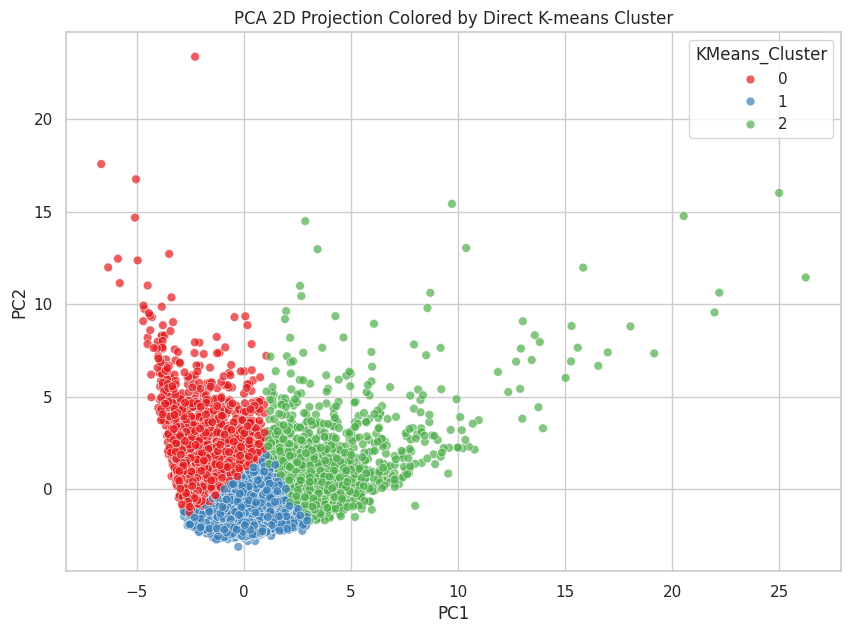

In [90]:
pca_kmeans_df = pca_df.copy()
pca_kmeans_df["KMeans_Cluster"] = kmeans_labels_direct

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_kmeans_df,
    x="PC1",
    y="PC2",
    hue="KMeans_Cluster",
    palette="Set1",
    alpha=0.7,
    s=40
)
plt.title("PCA 2D Projection Colored by Direct K-means Cluster")
plt.show()

Cell 51 — Save cluster assignments

In [91]:
cluster_assignments = pd.DataFrame({
    "CUST_ID": cust_ids,
    "SOM_Cluster": customer_clusters,
    "KMeans_Cluster": kmeans_labels_direct,
    "BMU_X": bmus[:, 0],
    "BMU_Y": bmus[:, 1]
})

cluster_assignments.to_csv("cluster_assignments.csv", index=False)
print("Saved cluster assignments to cluster_assignments.csv")
cluster_assignments.head()

Saved cluster assignments to cluster_assignments.csv


,CUST_ID,SOM_Cluster,KMeans_Cluster,BMU_X,BMU_Y
0,C10001,1,1,8,6
1,C10002,1,0,8,9
2,C10003,0,1,2,8
3,C10004,1,1,5,6
4,C10005,1,0,8,6


Cell 52 — Save preprocessed data with cluster labels

In [92]:
preprocessed_with_labels = df_model.copy()
preprocessed_with_labels["Cluster"] = customer_clusters
preprocessed_with_labels["CUST_ID"] = cust_ids.values

preprocessed_with_labels.to_csv("preprocessed_data_with_clusters.csv", index=False)
print("Saved preprocessed data with labels.")
preprocessed_with_labels.head()

Saved preprocessed data with labels.


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,PURCHASES_TO_LIMIT,PAYMENT_TO_MINPAY,BALANCE_TO_LIMIT,CASH_TO_PURCHASES,PURCHASE_SEGMENT,Cluster,CUST_ID
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,...,139.509787,0.000000,12.0,0.095400,1.446508,0.040901,0.000000e+00,0,1,C10001
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,...,1072.340217,0.222222,12.0,0.000000,3.826241,0.457495,6.442945e+09,0,1,C10002
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,...,627.284787,0.000000,12.0,0.103089,0.991682,0.332687,0.000000e+00,2,0,C10003
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,...,312.343947,0.000000,12.0,0.199867,0.000000,0.222223,1.372835e-01,2,1,C10004
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,...,244.791237,0.000000,12.0,0.013333,2.771075,0.681429,0.000000e+00,0,1,C10005


Cell 53 — Feature importance proxy using ANOVA top features

In [93]:
top_features = anova_df.sort_values("p_value").head(10)
top_features

,Feature,F_statistic,p_value
8,PURCHASES_INSTALLMENTS_FREQUENCY,10727.908195,0.000000e+00
2,PURCHASES,1490.759573,0.000000e+00
3,ONEOFF_PURCHASES,1316.819652,0.000000e+00
4,INSTALLMENTS_PURCHASES,1003.891586,0.000000e+00
6,PURCHASES_FREQUENCY,20491.812491,0.000000e+00
7,ONEOFF_PURCHASES_FREQUENCY,11221.745509,0.000000e+00
11,PURCHASES_TRX,2529.098333,0.000000e+00
12,CREDIT_LIMIT,478.838768,2.736849e-198
15,PRC_FULL_PAYMENT,422.704439,3.842936e-176
9,CASH_ADVANCE_FREQUENCY,331.076479,1.937279e-139



Cell 54 — Automatic cluster interpretation helper

In [94]:
overall_mean = clustered_df.drop(columns=["Cluster", "CUST_ID", "KMeans_Cluster"], errors="ignore").mean()

cluster_interpretation = {}

for cluster_id in sorted(clustered_df["Cluster"].unique()):
    cluster_mean = clustered_df[clustered_df["Cluster"] == cluster_id].drop(
        columns=["Cluster", "CUST_ID", "KMeans_Cluster"], errors="ignore"
    ).mean()
    
    diff = (cluster_mean - overall_mean).sort_values(ascending=False)
    top_high = diff.head(5).index.tolist()
    top_low = diff.tail(5).index.tolist()
    
    cluster_interpretation[cluster_id] = {
        "High Features": top_high,
        "Low Features": top_low
    }

cluster_interpretation

{0: {'High Features': ['CREDIT_LIMIT',
   'PURCHASES',
   'ONEOFF_PURCHASES',
   'PAYMENTS',
   'BALANCE'],
  'Low Features': ['BALANCE_FREQUENCY',
   'PRC_FULL_PAYMENT',
   'CASH_ADVANCE_FREQUENCY',
   'CASH_ADVANCE_TRX',
   'CASH_ADVANCE']},
 1: {'High Features': ['CASH_ADVANCE',
   'BALANCE',
   'CASH_ADVANCE_TRX',
   'CASH_ADVANCE_FREQUENCY',
   'BALANCE_FREQUENCY'],
  'Low Features': ['PAYMENTS',
   'INSTALLMENTS_PURCHASES',
   'ONEOFF_PURCHASES',
   'CREDIT_LIMIT',
   'PURCHASES']},
 2: {'High Features': ['INSTALLMENTS_PURCHASES',
   'MINIMUM_PAYMENTS',
   'PURCHASES_TRX',
   'PURCHASES_INSTALLMENTS_FREQUENCY',
   'PURCHASES_FREQUENCY'],
  'Low Features': ['ONEOFF_PURCHASES',
   'PAYMENTS',
   'CASH_ADVANCE',
   'BALANCE',
   'CREDIT_LIMIT']}}

Cell 56 — Suggested manual labels

In [95]:
manual_labels = {}

for cluster_id in sorted(clustered_df["Cluster"].unique()):
    manual_labels[cluster_id] = f"Segment_{cluster_id}"

manual_labels

{0: 'Segment_0', 1: 'Segment_1', 2: 'Segment_2'}

Cell 57 — Add segment labels

In [96]:
clustered_df["Segment_Label"] = clustered_df["Cluster"].map(manual_labels)
cluster_assignments["Segment_Label"] = cluster_assignments["SOM_Cluster"].map(manual_labels)

clustered_df.head()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster,CUST_ID,KMeans_Cluster,Segment_Label
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,...,2.0,1000.0,201.802084,139.509787,0.000000,12.0,1,C10001,1,Segment_1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,...,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,1,C10002,0,Segment_1
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,...,12.0,7500.0,622.066742,627.284787,0.000000,12.0,0,C10003,1,Segment_0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,...,1.0,7500.0,0.000000,312.343947,0.000000,12.0,1,C10004,1,Segment_1
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,...,1.0,1200.0,678.334763,244.791237,0.000000,12.0,1,C10005,0,Segment_1


Cell 58 — Executive summary table

In [97]:
executive_summary = clustered_df.groupby(["Cluster", "Segment_Label"]).agg(
    Customer_Count=("Cluster", "count"),
    Avg_Balance=("BALANCE", "mean"),
    Avg_Purchases=("PURCHASES", "mean"),
    Avg_Credit_Limit=("CREDIT_LIMIT", "mean"),
    Avg_Payments=("PAYMENTS", "mean")
).reset_index()

executive_summary["Percentage"] = round(executive_summary["Customer_Count"] / len(clustered_df) * 100, 2)
executive_summary

,Cluster,Segment_Label,Customer_Count,Avg_Balance,Avg_Purchases,Avg_Credit_Limit,Avg_Payments,Percentage
0,0,Segment_0,1682,2181.491267,3134.944174,6824.630851,3240.332007,18.79
1,1,Segment_1,4757,1647.392659,268.977166,4077.886878,1440.841175,53.15
2,2,Segment_2,2511,994.079855,966.221736,3722.139053,1277.306878,28.06


Cell 59 — Export executive summary

In [98]:
executive_summary.to_csv("executive_summary.csv", index=False)
print("Executive summary saved.")

Executive summary saved.


Cell 60 — Final business insight print block

In [99]:
for _, row in executive_summary.iterrows():
    print(f"""
Cluster {row['Cluster']} ({row['Segment_Label']}):
- Customers: {row['Customer_Count']} ({row['Percentage']}%)
- Avg Balance: {row['Avg_Balance']:.2f}
- Avg Purchases: {row['Avg_Purchases']:.2f}
- Avg Credit Limit: {row['Avg_Credit_Limit']:.2f}
- Avg Payments: {row['Avg_Payments']:.2f}
""")


Cluster 0 (Segment_0):
- Customers: 1682 (18.79%)
- Avg Balance: 2181.49
- Avg Purchases: 3134.94
- Avg Credit Limit: 6824.63
- Avg Payments: 3240.33


Cluster 1 (Segment_1):
- Customers: 4757 (53.15%)
- Avg Balance: 1647.39
- Avg Purchases: 268.98
- Avg Credit Limit: 4077.89
- Avg Payments: 1440.84


Cluster 2 (Segment_2):
- Customers: 2511 (28.06%)
- Avg Balance: 994.08
- Avg Purchases: 966.22
- Avg Credit Limit: 3722.14
- Avg Payments: 1277.31



Cell 61 — Marketing recommendations template

In [100]:
recommendations = {
    "High-value spenders": "Offer premium rewards, higher credit-line upgrades, exclusive merchant offers.",
    "Dormant users": "Run reactivation campaigns, cashback offers, and personalized reminders.",
    "Cash-advance heavy users": "Promote repayment planning and lower-interest conversion products.",
    "Low-limit cautious users": "Offer credit-building products and safe spending nudges.",
    "Balanced regular users": "Use cross-sell offers for insurance, EMI plans, and loyalty benefits."
}

recommendations

{'High-value spenders': 'Offer premium rewards, higher credit-line upgrades, exclusive merchant offers.',
 'Dormant users': 'Run reactivation campaigns, cashback offers, and personalized reminders.',
 'Cash-advance heavy users': 'Promote repayment planning and lower-interest conversion products.',
 'Low-limit cautious users': 'Offer credit-building products and safe spending nudges.',
 'Balanced regular users': 'Use cross-sell offers for insurance, EMI plans, and loyalty benefits.'}

Cell 62 — Optional: Hexagonal topology note


In [101]:
print("""
MiniSom mainly supports rectangular grids directly.
For assignment discussion, mention that rectangular topology was used for implementation simplicity,
while hexagonal topology can sometimes preserve neighborhood smoothness better.
""")


MiniSom mainly supports rectangular grids directly.
For assignment discussion, mention that rectangular topology was used for implementation simplicity,
while hexagonal topology can sometimes preserve neighborhood smoothness better.



Cell 63 — Final observations markdown cell content

In [102]:
print("""
Final Observations:
1. SOM preserves topological relationships by placing similar customers in nearby neurons.
2. U-Matrix helped identify boundaries between customer groups.
3. Component planes showed which variables drive segmentation.
4. SOM-based clustering provided an interpretable 2D structure before cluster extraction.
5. Comparison with K-means helped validate whether the discovered segments were consistent.
""")


Final Observations:
1. SOM preserves topological relationships by placing similar customers in nearby neurons.
2. U-Matrix helped identify boundaries between customer groups.
3. Component planes showed which variables drive segmentation.
4. SOM-based clustering provided an interpretable 2D structure before cluster extraction.
5. Comparison with K-means helped validate whether the discovered segments were consistent.



Cell 64 — Save final processed dataframe

In [103]:
clustered_df.to_csv("final_customer_segments.csv", index=False)
print("Saved final_customer_segments.csv")

Saved final_customer_segments.csv
